In [78]:
import matplotlib.pyplot as plt
import numpy as np
from PySpice.Spice.Netlist import Circuit, SubCircuit
from PySpice.Unit import *

class ZhangThresholdMemristor(SubCircuit):
    __nodes__ = ('TE', 'BE')

    def __init__(self, 
                 name='ZhangMemristor',
                 R_on=10.0,
                 R_off=420.0,
                 Vt_plus=0.37,
                 Vt_minus=-0.19,
                 mu_v=1.6e-12,
                 D=3e-9,
                 i_on=1e-3,
                 i_off=1e-5,
                 i_0=1e-3):
        
        # Fixed: Removed 'self' from super() to comply with Python 3 inheritance
        super().__init__(name, *self.__nodes__)
        
        # 1. The Dummy Ammeter
        self.VoltageSource('sense', 'TE', 'TE_int', 0@u_V)
        
        # 2. The Puppet Resistor
        self.BehavioralSource('G_puppet', 'TE_int', 'BE', 
            i=f'(V(TE_int) - V(BE)) / ({R_on} * (V(w)/{D}) + {R_off} * (1.0 - (V(w)/{D})))'
        )
        
        # 3. The Memory Bucket
        self.Capacitor('C_state', 'w', '0', 1@u_F)
        
        # 4. The Valve & Brake
        window_func = f'(1.0 - (2.0 * V(w)/{D} - 1.0)^2)'
        dw_dt_pos = f'({mu_v} * ({R_on}/{D}) * ({i_on} / (abs(I(Vsense)) - {i_0} + 1e-12)) * {window_func})'
        dw_dt_neg = f'({mu_v} * ({R_on}/{D}) * (abs(I(Vsense)) / {i_off}) * {window_func})'
        
        eq5 = f'(V(TE) - V(BE)) > {Vt_plus} ? {dw_dt_pos} : ((V(TE) - V(BE)) < {Vt_minus} ? {dw_dt_neg} : 0.0)'
        self.BehavioralSource('G_state', '0', 'w', i=eq5)
        
        # 5. SPICE Safety Clamps
        self.BehavioralSource('G_clip', 'w', '0', 
            i=f'V(w) > {D} ? -1e6*(V(w)-{D}) : (V(w) < {0.001*D} ? 1e6*({0.001*D}-V(w)) : 0)'
        )


# ==========================================
# SIMULATION INITIALIZATION
# ==========================================
circuit = Circuit('Zhang Memristor Simulation')

# Register the subcircuit
circuit.subcircuit(ZhangThresholdMemristor(name='ZhangMemristor'))

# Stimulus: 0.5V amplitude crosses both Vt_plus (0.37V) and Vt_minus (-0.19V)
circuit.SinusoidalVoltageSource('in', 'node_in', circuit.gnd, amplitude=0.5@u_V, frequency=1@u_Hz)

# Top-level dummy ammeter to safely extract I_mem without querying subcircuit internals
circuit.VoltageSource('meas', 'node_in', 'node_TE', 0@u_V)

# Instantiate the memristor
circuit.X('mem1', 'ZhangMemristor', 'node_TE', circuit.gnd)


# ==========================================
# RUN ANALYSIS
# ==========================================
simulator = circuit.simulator(temperature=25, nominal_temperature=25)
print(circuit)
# uic=True (Use Initial Conditions) is critical here so the state capacitor 'w' integrates properly from 0
analysis = simulator.transient(step_time=1@u_ms, end_time=3@u_s, use_initial_condition=True)


# ==========================================
# DATA EXTRACTION & PLOTTING
# ==========================================
time = np.array(analysis.time)
V_mem = np.array(analysis['node_TE'])
I_mem = np.array(analysis.branches['vmeas'])

# Calculate Memristance, masking near-zero current regions to avoid division by zero spikes
R_mem = np.zeros_like(V_mem)
valid = np.abs(I_mem) > 1e-8
R_mem[valid] = V_mem[valid] / I_mem[valid]
R_mem[~valid] = np.nan

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Memristance vs Time
ax1.plot(time, R_mem, color='#1f77b4', linewidth=2)
ax1.set_title('Simulated Memristance vs Time')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Memristance (Ω)')
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot 2: I-V Curve
ax2.plot(V_mem, I_mem * 1000.0, color='#d62728', linewidth=2)
ax2.set_title('I-V Curve (Pinched Hysteresis)')
ax2.set_xlabel('Voltage (V)')
ax2.set_ylabel('Current (mA)')
ax2.axvline(0, color='black', linewidth=0.5)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

.title Zhang Memristor Simulation
.subckt ZhangMemristor TE BE
Vsense TE TE_int 0V
BG_puppet TE_int BE i=(V(TE_int) - V(BE)) / (10.0 * (V(w)/3e-09) + 420.0 * (1.0 - (V(w)/3e-09)))
CC_state w 0 1
BG_state 0 w i=(V(TE) - V(BE)) > 0.37 ? (1.6e-12 * (10.0/3e-09) * (0.001 / (abs(I(Vsense)) - 0.001 + 1e-12)) * (1.0 - (2.0 * V(w)/3e-09 - 1.0)^2)) : ((V(TE) - V(BE)) < -0.19 ? (1.6e-12 * (10.0/3e-09) * (abs(I(Vsense)) / 1e-05) * (1.0 - (2.0 * V(w)/3e-09 - 1.0)^2)) : 0.0)
BG_clip w 0 i=V(w) > 3e-09 ? -1e6*(V(w)-3e-09) : (V(w) < 3e-12 ? 1e6*(3e-12-V(w)) : 0)
.ends ZhangMemristor
Vin node_in 0 DC 0V AC 1V SIN(0V 0.5V 1Hz 0s 0Hz)
Vmeas node_in node_TE 0V
Xmem1 node_TE 0 ZhangMemristor



NgSpiceCommandError: Command 'run' failed

starting on some nonchalant shit
-------------starting building sequence----------------------


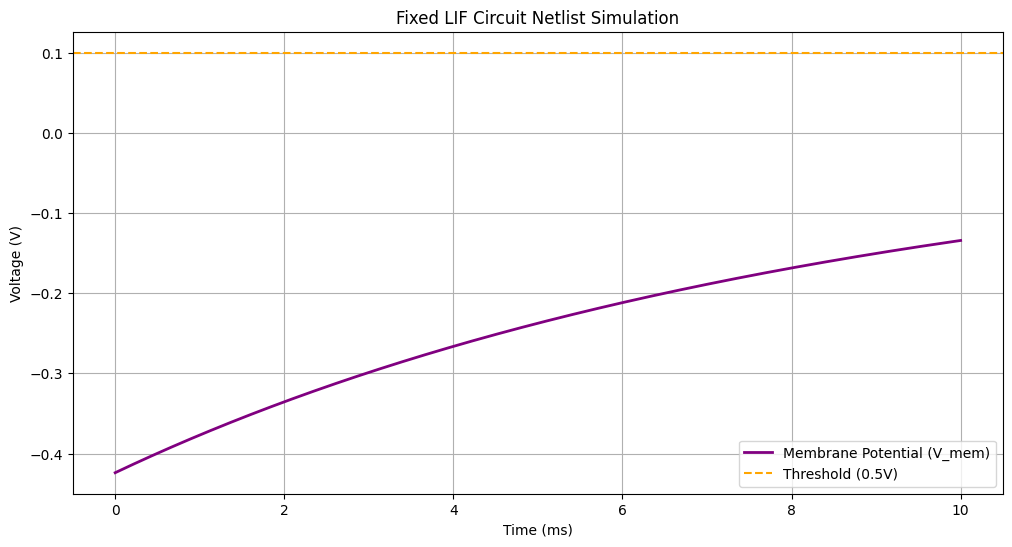

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from PySpice.Spice.Netlist import Circuit, SubCircuit
from PySpice.Unit import *
import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()

# ==========================================
# 1. DEFINE THE BEHAVIORAL MEMRISTOR SUBCIRCUIT     
# ==========================================
class BehavioralMemristor(SubCircuit):
    name = 'memristor'
    __nodes__ = ('p', 'n')

    def __init__(self, R_init=10e3, R_lrs=1e3, R_hrs=100e3, threshold_v=0.1, rate=1e5, name=name):
        SubCircuit.__init__(self, name, *self.__nodes__)
        
        # FIX 1 & 2: Use i= for G-sources and convert V(p,n) to (V(p)-V(n))
        self.BehavioralSource('Gstate', 'w', '0', 
            i=f'((V(p)-V(n)) > {threshold_v}) ? {rate} * ((V(p)-V(n)) - {threshold_v}) : '
              f'(((V(p)-V(n)) < -{threshold_v}) ? {rate} * ((V(p)-V(n)) + {threshold_v}) : 0)'
        )
        
        # State capacitor
        self.Capacitor('Cstate', 'w', '0', 10@u_uF, ic=R_init/R_hrs)
        
        # FIX 3: Add a anti-floating resistor to clear DC convergence bugs
        self.Resistor('R_gnd_w', 'w', '0', 1@u_GΩ)
        
        # FIX 1: Convert to i= current source for Gclip
        self.BehavioralSource('Gclip', 'w', '0', 
            i='V(w) > 1.0 ? -1e6*(V(w)-1.0) : (V(w) < 0.001 ? 1e6*(0.001-V(w)) : 0)'
        )
        
        # FIX 1: Convert to i= current source (I = V / R)
        self.BehavioralSource('Gmem', 'p', 'n', 
            i=f'(V(p) - V(n)) / ({R_hrs} * (1.0 - V(w)) + {R_lrs} * V(w))'
        )

# ==========================================
# 2. CONSTRUCT THE SNN CIRCUIT
# ==========================================
def build_lif_circuit(positive_spike_times, negative_spike_times, sim_duration_ms=10):
    print("-------------starting building sequence----------------------")
    circuit = Circuit('Memristive Leaky Integrate and Fire Neuron')
    
    circuit.subcircuit(BehavioralMemristor(R_init=50e3, R_lrs=2e3, R_hrs=100e3))
    
    # Positive Rail Pulse train
    pwl_pos = [(0, 0)]
    for t_ms in positive_spike_times: 
        pwl_pos.extend([(t_ms - 0.01, 0), (t_ms, 1.2), (t_ms + 0.1, 1.2), (t_ms + 0.11, 0)])
    circuit.PieceWiseLinearVoltageSource('Vpos', 'in_pos', '0', values=pwl_pos)
    
    # Negative Rail Pulse train
    pwl_neg = [(0, 0)]
    for t_ms in negative_spike_times:
        pwl_neg.extend([(t_ms - 0.01, 0), (t_ms, 1.2), (t_ms + 0.1, 1.2), (t_ms + 0.11, 0)])
    circuit.PieceWiseLinearVoltageSource('Vneg', 'in_neg', '0', values=pwl_neg)

    # Excitatory Path
    circuit.X('Xmem_pos', 'memristor', 'in_pos', 'mem_node')
    
    # FIX 4: Corrected inhibitory configuration.
    # Connects mem_node through the memristor directly to a negative sink pull-down.
    circuit.VoltageSource('Vsink', 'sink_node', '0', -1.2@u_V)
    circuit.X('Xmem_neg', 'memristor', 'mem_node', 'sink_node') 

    # Neuron Integrator (RC)
    circuit.Capacitor('Cmem', 'mem_node', '0', 4.7@u_uF, ic=0.0)
    circuit.Resistor('Rleak', 'mem_node', '0', 2.2@u_kΩ)

    # SPICE Comparator & Reset Switch
    circuit.model('ResetSwitchModel', 'SW', Ron=1@u_Ω, Roff=1@u_MΩ, Vt=0.5@u_V, Vh=0.05@u_V)
    circuit.VoltageControlledSwitch('Sreset', 'mem_node', '0', 'mem_node', '0', model='ResetSwitchModel')

    return circuit

if __name__ == "__main__":
    print("starting on some nonchalant shit")
    import json
    import numpy as np

    with open("../shared_data.json", "r") as file:
        imported_data = json.load(file)

    # 1. Load the dense array (comment out the print to stop terminal flooding)
    pos_spikes_raw = imported_data["my_variable"]
    
    sim_ms = 10.0
    dt_ms = sim_ms / len(pos_spikes_raw)
    
    # 2. Convert dense STBP array to sparse spike times
    pos_spikes = []
    last_spike_t = -1.0
    
    for i, val in enumerate(pos_spikes_raw):
        if val > 0.5:  # Threshold to classify as a hard spike
            t_ms = i * dt_ms
            # Ensure pulses do not overlap (your PWL pulse width is 0.12ms)
            if t_ms > last_spike_t + 0.12:
                pos_spikes.append(t_ms)
                last_spike_t = t_ms

    # 3. Ensure manually written sparse arrays are strictly sorted
    neg_spikes = sorted([4.0, 4.5, 5.0, 9.0])
    
    circuit = build_lif_circuit(pos_spikes, neg_spikes, sim_duration_ms=sim_ms)
    
    # --- Simulator Execution ---
    simulator = circuit.simulator(temperature=25, nominal_temperature=25)
    analysis = simulator.transient(step_time=0.01@u_ms, end_time=sim_ms@u_ms)
    
    time = np.array(analysis.time) * 1000 
    v_mem = np.array(analysis['mem_node'])
    v_pos = np.array(analysis['in_pos'])
    
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 6))
    plt.plot(time, v_mem, color='purple', linewidth=2, label='Membrane Potential (V_mem)')
    plt.axhline(.1, color='orange', linestyle='--', label='Threshold (0.5V)')
    plt.title("Fixed LIF Circuit Netlist Simulation")
    plt.xlabel("Time (ms)")
    plt.ylabel("Voltage (V)")
    plt.legend()
    plt.grid(True)
    plt.show()

{'XMem1.Cmem': 0}


C:\Users\Asus\AppData\Local\Temp\ipykernel_16948\3388120703.py:136: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


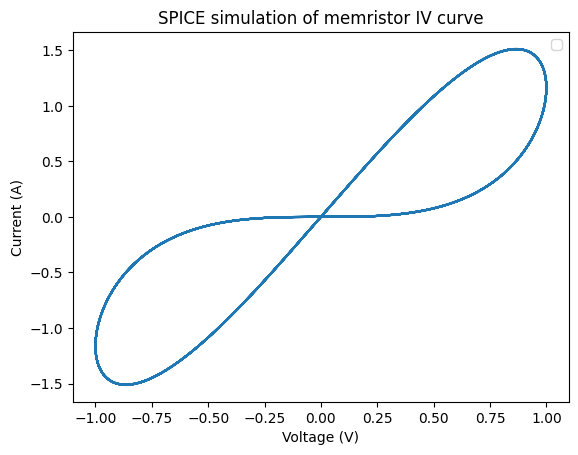

In [12]:
# memristor from https://arxiv.org/pdf/1711.06819

import matplotlib.pyplot as plt
import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit, SubCircuit
from PySpice.Unit import *
import os
import numpy as np

def get_all_nodes_Cmem(circuit):
    # this only works for the first level of subcircuits
    nodes = []
    for subcircuit in circuit.subcircuits:
        for node in subcircuit.nodes:
            if node.name.lower() == 'cmem':
                nodes.append(("X"+subcircuit.name+"."+node.name).lower())
    return nodes

def get_all_nodes_recursive(circuit, currentName):
    nodes = []
    for subcircuit in circuit.subcircuits:
        if currentName == "":
            subcircuitName = "X" + subcircuit.name
        else:
            subcircuitName = currentName + ".X" + subcircuit.name
        for node in subcircuit.nodes:
            if node.name != circuit.gnd:
                nodes.append(subcircuitName + "." + node.name)
        nodes += get_all_nodes_recursive(subcircuit, subcircuitName)
    return nodes

def get_all_cmem_nodes_recursive(circuit):
    all_nodes = get_all_nodes_recursive(circuit, "")
    cmem_nodes = []
    for node in all_nodes:
        if node.lower().find("cmem") != -1:
            cmem_nodes.append(node)
    return cmem_nodes

def add_initial_condition(simulator, circuit):
    kwargDict = {}
    IC = 0
    for n in get_all_cmem_nodes_recursive(circuit):
        kwargDict[n] = IC
    print(kwargDict)
    simulator.initial_condition(**kwargDict)


class Memristor(SubCircuit):
    def __init__(self, name, K=0.00005, Kp=0.13*10**-3, C=0.1@u_pF, Vto=0, SwitchRoff=10**20, SwitchRon=10**-3):
        __nodes__ = ('S', 'D', 'phi')
        SubCircuit.__init__(self, name, *__nodes__)
        # self.parameters = {'K': K, 'Kp': Kp, 'C': C, 'Vto': Vto}
        self.VCCS('m', self.gnd, 'o', 'D', 'S', K)
        self.R('R2', 'o', self.gnd, 10**12)
        self.VoltageControlledSwitch('sw', 'o', 'Cmem', 'phi', self.gnd, model='my_switch')
        self.model('my_switch', "SW", Ron=SwitchRon, Roff=SwitchRoff, Vt=0.5)
        self.C('C', self.gnd, 'Cmem', C)
        self.model('my_nmos', 'NMOS', level=3, Vto=Vto, Kp=Kp)
        # M1 drain gate source body
        self.MOSFET(1, 'D', 'Cmem', 'S', self.gnd, model='my_nmos')

class MemristorsInSeries(SubCircuit):
    def __init__(self, name, K=0.00045, Kp=0.13*10**-3, C=0.1@u_pF, Vto=0, N=3):
        __nodes__ = ('S', 'D')
        SubCircuit.__init__(self, name, *__nodes__)
        # self.parameters = {'K': K, 'Kp': Kp, 'C': C, 'Vto': Vto}
        self.subcircuit(Memristor('Mem0', K=K, Kp=Kp, C=C, Vto=Vto))
        self.X('Mem0', 'mem0', 'S', 'o0')
        for i in range(1, N):
            self.subcircuit(Memristor('Mem'+str(i), K=K, Kp=Kp, C=C, Vto=Vto))
            self.X('Mem'+str(i), 'mem'+str(i), 'o'+str(i-1), 'o'+str(i))
        self.subcircuit(Memristor('Mem'+str(N), K=K, Kp=Kp, C=C, Vto=Vto))
        self.X('Mem'+str(N), 'mem'+str(N), 'o'+str(N-1), 'D')

def testMemristorInSeries():
    # memristors in series test
    vs = 0
    vd = 0.2
    circuit = Circuit('NMOS Transistor')
    circuit.V('S', 'S', circuit.gnd, vs@u_V)
    circuit.SinusoidalVoltageSource('D', 'D', circuit.gnd, amplitude=vd@u_V, frequency=1@u_kHz)
    circuit.subcircuit(MemristorsInSeries('SMem1', K=0.00045, Kp=0.13*10**-3, C=0.1@u_pF, Vto=0, N=3))
    circuit.X('SMem1', 'smem1', 'S', 'D')

    print(circuit)

    simulator = circuit.simulator(temperature=25, nominal_temperature=25)
    add_initial_condition(simulator, circuit)
    # kwargDict = {}
    # IC = 0
    # for n in get_all_cmem_nodes_recursive(circuit):
    #     kwargDict[n] = IC
    # print(kwargDict)
    # simulator.initial_condition(**kwargDict)
    analysis = simulator.transient(step_time=0.0001@u_ms, end_time=10@u_ms)

    # plot drain current at vd
    plt.plot(np.array(analysis.branches['vd']), label='Id')
    plt.legend()
    plt.show()

    # vd vs ID
    vds = np.array(analysis['D']) - np.array(analysis['S'])

    figure, ax = plt.subplots(figsize=(20, 10))
    plt.plot(vds, -np.array(analysis.branches['vd']), label='ID')
    plt.legend()

    plt.show()


if __name__ == '__main__':
    vs = 0
    vd = 1
    phi = 1.2
    circuit = Circuit('NMOS Transistor')
    circuit.V('S', 'S', circuit.gnd, vs@u_V)
    circuit.SinusoidalVoltageSource('D', 'D', circuit.gnd, amplitude=vd@u_V, frequency=1@u_kHz, offset=0@u_V)
    circuit.subcircuit(Memristor('Mem1', K=0.0002, Kp=0.13*10**-3, C=0.1@u_pF, Vto=0))
    circuit.V('phi', 'phi', circuit.gnd, phi@u_V)
    circuit.X('Mem1', 'mem1', 'S', 'D', 'phi')
    simulator = circuit.simulator(temperature=25, nominal_temperature=25)
    # IMPORTANT! the initial condition is neccesary for capacitor to work
    add_initial_condition(simulator, circuit)

    analysis = simulator.transient(step_time=0.0001@u_ms, end_time=10@u_ms, use_initial_condition=True)

    # vd vs ID
    vds = np.array(analysis['D']) - np.array(analysis['S'])
    plt.plot(vds, np.array(analysis.branches['vs']))
    plt.legend()
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (A)')
    plt.title("SPICE simulation of memristor IV curve")
    plt.savefig('memristor_circuit_simulation.png')
    plt.show()

In [1]:
# memristor from https://ieeexplore.ieee.org/document/7558224/
import matplotlib.pyplot as plt
import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit, SubCircuit
from PySpice.Unit import *
import os
import numpy as np

def get_all_nodes_Cmem(circuit):
    # this only works for the first level of subcircuits
    nodes = []
    for subcircuit in circuit.subcircuits:
        for node in subcircuit.nodes:
            if node.name.lower() == 'cmem':
                nodes.append(("X"+subcircuit.name+"."+node.name).lower())
    return nodes

def get_all_nodes_recursive(circuit, currentName):
    nodes = []
    for subcircuit in circuit.subcircuits:
        if currentName == "":
            subcircuitName = "X" + subcircuit.name
        else:
            subcircuitName = currentName + ".X" + subcircuit.name
        for node in subcircuit.nodes:
            if node.name != circuit.gnd:
                nodes.append(subcircuitName + "." + node.name)
        nodes += get_all_nodes_recursive(subcircuit, subcircuitName)
    return nodes

def get_all_cmem_nodes_recursive(circuit):
    all_nodes = get_all_nodes_recursive(circuit, "")
    cmem_nodes = []
    for node in all_nodes:
        if node.lower().find("cmem") != -1:
            cmem_nodes.append(node)
    return cmem_nodes

def add_initial_condition(simulator, circuit):
    kwargDict = {}
    IC = 0
    for n in get_all_cmem_nodes_recursive(circuit):
        kwargDict[n] = IC
    print(kwargDict)
    simulator.initial_condition(**kwargDict)

 

{'XMem1.Cmem': 0}


C:\Users\Asus\AppData\Local\Temp\ipykernel_16948\2036678487.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


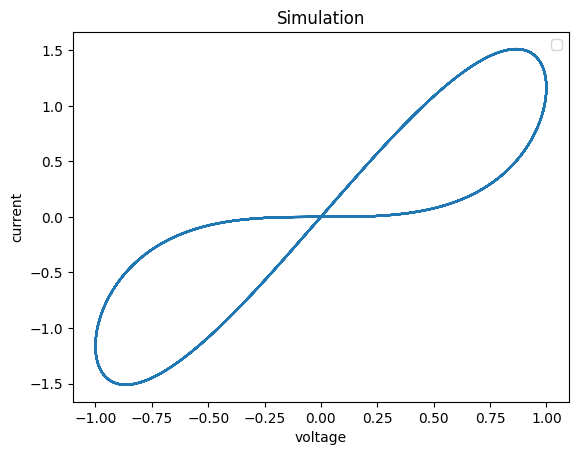

__main__


In [34]:
if __name__ == '__main__':
    vs = 0
    vd = 1
    phi = 3
    circuit = Circuit("nm")
    circuit.V("S", "S", circuit.gnd, vs@u_V)
    circuit.SinusoidalVoltageSource("D", "D", circuit.gnd, amplitude=vd@u_V, frequency=1@u_kHz, offset=0@u_V)
    circuit.subcircuit(Memristor("Mem1", K=0.0002, Kp=.13e-3, C=.1@u_pF, Vto=0))
    circuit.V("phi", 'phi', circuit.gnd, phi@u_V)
    circuit.X("Mem1", 'mem1', 'S', 'D', 'phi')
    simulator  = circuit.simulator(temperature=25, nominal_temperature=25)
    add_initial_condition(simulator, circuit)
    
    analysis = simulator.transient(step_time=.0001@u_ms, end_time=10@u_ms, use_initial_condition=True)
    
    vds = np.array(analysis['D']) - np.array(analysis["S"])
    plt.plot(vds, np.array(analysis.branches['vs']))
    plt.legend()
    plt.xlabel("voltage")
    plt.ylabel("current")
    plt.title("Simulation")
    plt.savefig('memristor_circuit_simulation.png')
    plt.show()

print(__name__)



.title Mmem
.subckt zhangMemristor TE BE w
BR_behavioral TE BE i=(V(TE) - V(BE)) / (1000000.0 * (V(w)/3) + 60000000.0 * (1.0 - (V(w)/3)))
CC_state w 0 15 ic=1.5
BGstate 0 w i=( (V(TE) - V(BE)) > 1.2 ) ? ( 3.2e-15 * (1000000.0/3) * (1.4e-14 / (((V(TE) - V(BE)) / (1000000.0 * (V(w)/3) + 60000000.0 * (1.0 - (V(w)/3)))) - 3e-08)) * (1.0 - pow((2.0 * (V(w) / 3) - 1.0), 4)) ) : ( ( (V(TE) - V(BE)) < -2.4 ) ? ( 3.2e-15 * (1000000.0/3) * (((V(TE) - V(BE)) / (1000000.0 * (V(w)/3) + 60000000.0 * (1.0 - (V(w)/3)))) / 1) * (1.0 - pow((2.0 * (V(w) / 3) - 1.0), 4)) ) : 0.0 )
.ends zhangMemristor
VD D 0 DC 0V PULSE(0V 0.6V 0.0001ms 1us 1us 0.25ms 0.5ms)
Xmmem1 D 0 w_state zhangMemristor



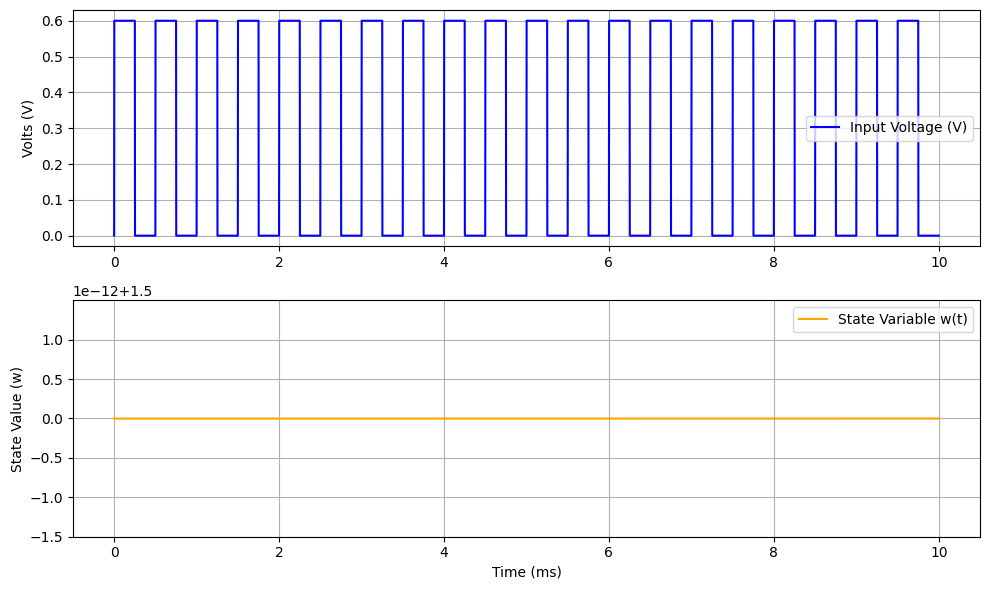

1.4999999999999998 V 1.4999999999999978 V
{'vd': WaveForm vd [0. 0. 0. ... 0. 0. 0.]@A}


C:\Users\Asus\AppData\Local\Temp\ipykernel_32248\1868903887.py:176: RuntimeWarning: Degrees of freedom <= 0 for slice.
  R_var[i] = np.nanvar(segment)


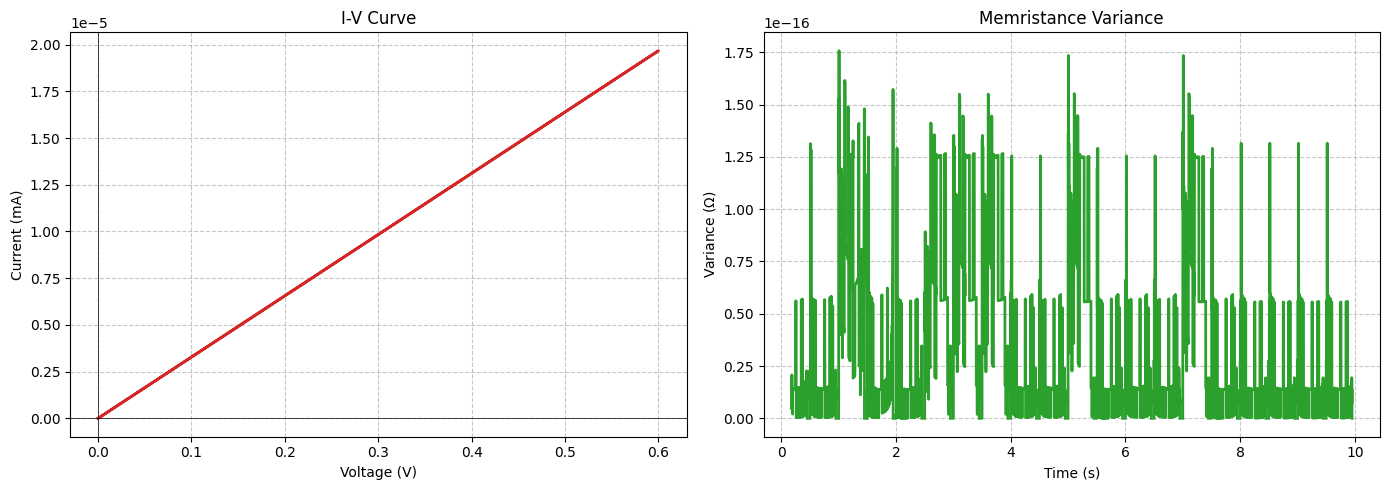

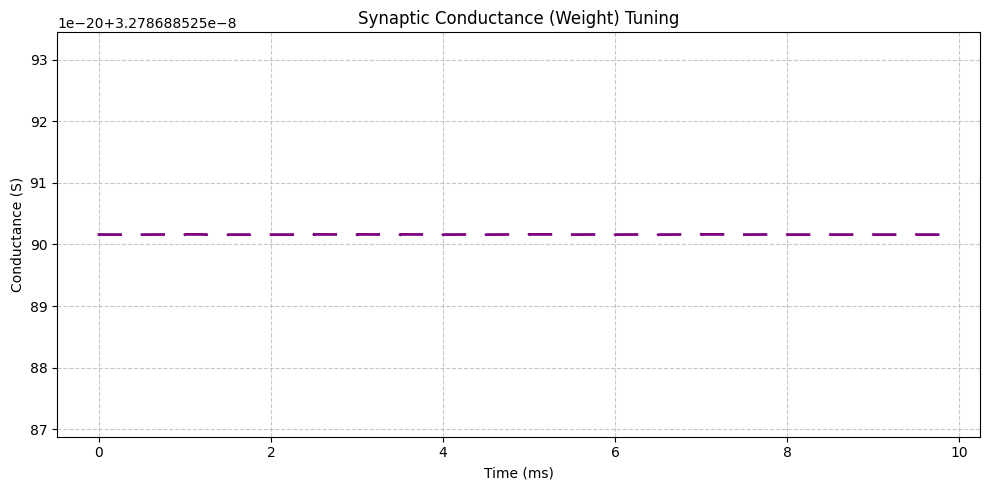

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from PySpice.Spice.Netlist import Circuit, SubCircuit
from PySpice.Unit import *
import PySpice.Logging.Logging as Logging
import PySpice.Spice.NgSpice.Shared as NgSpiceShared
import PySpice
logger = Logging.setup_logging()

# Parameters
# Ron = 1e3
# Roff = 100e3 
# Vtp = .3 
# Vtn = -.3
# mu_v = 1e-10 * 6.546537e+04
# D = 3
# ion = 3e-5
# ioff = 9e-5
# i0 = 1e-6
# p = 2
 
Ron = 1e6
Roff = 6e7 
Vtp = 1.2
Vtn = -2.4
mu_v = 3.2e-15
D = 3
ion = 1
ioff = 1.4e-14
i0 = 3e-8
p = 2
 


import math

# Cleaned expressions using explicit local subcircuit nodes
window_function = f"(1.0 - pow((2.0 * (V(w) / {D}) - 1.0), {2 * p}))"     
R_w = f"({Ron} * (V(w)/{D}) + {Roff} * (1.0 - (V(w)/{D})))"
i_t = f"((V(TE) - V(BE)) / {R_w})"
 
class Memristor(SubCircuit):
    __nodes__ = ("TE", "BE", "w")
    def __init__(self, name):
        SubCircuit.__init__(self, name, *self.__nodes__)
        
        self.BehavioralSource('R_behavioral', 'TE', 'BE', i=f"(V(TE) - V(BE)) / {R_w}")
         
        self.Capacitor('C_state', 'w', '0', 15@u_F, ic=1.5)
        
        expression = (
            f"( (V(TE) - V(BE)) > {Vtp} ) ? "
            f"( {mu_v} * ({Ron}/{D}) * ({ioff} / ({i_t} - {i0})) * {window_function} ) : "
            f"( ( (V(TE) - V(BE)) < {Vtn} ) ? "
            f"( {mu_v} * ({Ron}/{D}) * ({i_t} / {ion}) * {window_function} ) : 0.0 )"
        )
                     
        self.BehavioralSource('Gstate', '0', 'w', i=expression)
         


circuit = Circuit("Mmem")
circuit.subcircuit(Memristor(name="zhangMemristor"))
pwl_coords = [(0@u_s, 0@u_V)]

# period = 0.5e-3       # 0.5 ms total period
# pulse_width = 0.25e-3  # 0.25 ms high time
# edge_time = 1e-6       # small rise/fall time

# def add_pulse_train(level, start_t, duration_s):
#     coords = []
#     t = start_t
#     end_t = start_t + duration_s

#     while t < end_t:
#         # low -> high
#         coords.append((t@u_s, 0@u_V))
#         coords.append(((t + edge_time)@u_s, level@u_V))

#         # hold high
#         coords.append(((t + pulse_width)@u_s, level@u_V))

#         # high -> low
#         coords.append(((t + pulse_width + edge_time)@u_s, 0@u_V))

#         # hold low until next pulse
#         t += period

#     return coords, t

# # 0 ↔ 1 for first 5 ms
# coords, current_t = add_pulse_train(1, 0.0, 5e-3)
# pwl_coords.extend(coords)

# # 0 ↔ -1 for next 5 ms
# coords, current_t = add_pulse_train(-1, current_t, 5e-3)
# pwl_coords.extend(coords)

# circuit.PieceWiseLinearVoltageSource('D', 'D', circuit.gnd, values=pwl_coords)
 

circuit.PulseVoltageSource(
    "D", "D", circuit.gnd,
    initial_value=0@u_V, pulsed_value=0.6@u_V,  
    delay_time=0.0001@u_ms,
    rise_time=1@u_us, fall_time=1@u_us,   
    pulse_width=.25@u_ms, period=.5@u_ms
)

# pwl_coords = [(0@u_s, 0@u_V), (1@u_ns, -0.6@u_V)]

# current_t = 1e-9         # Start tracking time from 1ns
# half_period = 0.25e-3    # 0.25 ms (matches your 0.25ms pulse width)
# edge_time = 1e-6         # 1 microsecond rise/fall time

# # Loop to generate enough cycles to cover the full 10ms simulation
# for _ in range(25): 
#     # Hold at -0.6V for the negative half of the period
#     current_t += (half_period - edge_time)
#     pwl_coords.append((current_t@u_s, -0.6@u_V))
    
#     # Rise to +0.6V
#     current_t += edge_time
#     pwl_coords.append((current_t@u_s, 0.6@u_V))
    
#     # Hold at +0.6V for the positive half of the period
#     current_t += (half_period - edge_time)
#     pwl_coords.append((current_t@u_s, 0.6@u_V))
    
#     # Fall back to -0.6V to start the next cycle
#     current_t += edge_time
#     pwl_coords.append((current_t@u_s, -0.6@u_V))

# Feed the generated coordinate array into the SPICE netlist
# circuit.PieceWiseLinearVoltageSource('D', 'D', circuit.gnd, values=pwl_coords)
circuit.X('mmem1', 'zhangMemristor', "D", circuit.gnd, "w_state")

print(circuit)

simulator = circuit.simulator(temperature=25, nominal_temperature=25)
analysis = simulator.transient(step_time=0.001@u_ms, end_time=10@u_ms, use_initial_condition=True)
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(np.array(analysis.time)*1000, np.array(analysis['D']), label='Input Voltage (V)', color='blue')
plt.ylabel('Volts (V)')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
# Access the node using its global name assigned by PySpice
plt.plot(np.array(analysis.time)*1000, np.array(analysis['w_state']), label='State Variable w(t)', color='orange')
plt.xlabel('Time (ms)')
plt.ylabel('State Value (w)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
print(max(analysis['w_state']), min(analysis['w_state']))
print(analysis.branches)
time = np.array(analysis.time)
V_mem = np.array(analysis['D'])
I_mem = np.array(analysis.branches['vd'])  # current through the voltage source named 'D'

# Memristance
R_mem = np.full_like(V_mem, np.nan, dtype=float)
valid = np.abs(I_mem) > 1e-8
R_mem[valid] = V_mem[valid] / I_mem[valid]

# Rolling variance of memristance
window = max(5, len(R_mem) // 50)
R_var = np.full_like(R_mem, np.nan, dtype=float)
for i in range(window - 1, len(R_mem)):
    segment = R_mem[i - window + 1:i + 1]
    R_var[i] = np.nanvar(segment)

fig, (ax1, ax2) = plt.subplots(1, 2,  figsize=(14, 5))

# I-V curve
ax1.plot(V_mem, -I_mem * 1000.0, color='#d62728', linewidth=2)
ax1.set_title('I-V Curve')
ax1.set_xlabel('Voltage (V)')
ax1.set_ylabel('Current (mA)')
ax1.axvline(0, color='black', linewidth=0.5)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.grid(True, linestyle='--', alpha=0.7)

 
# variance
ax2.plot(time*1000, R_var, color='#2ca02c', linewidth=2)
ax2.set_title('Memristance Variance')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Variance ($\Omega$)')
ax2.grid(True, linestyle='--', alpha=0.7)

# Conductance (G = 1/R)
G_mem = -1.0 / R_mem
 

plt.tight_layout()
plt.show()
# --- Conductance Plot ---
plt.figure(figsize=(10, 5))
# We plot it over time. Multiply time by 1000 to convert seconds to ms.
plt.plot(time * 1000, G_mem, color='purple', linewidth=2)
plt.title('Synaptic Conductance (Weight) Tuning')
plt.xlabel('Time (ms)')
plt.ylabel('Conductance (S)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [35]:
def add_pulse_train(level, start_t, duration_s):
    coords = []
    t = start_t
    end_t = start_t + duration_s

    while t < end_t:
        coords.append((t@u_s, 0@u_V))
        coords.append(((t + edge_time)@u_s, level@u_V))
        coords.append(((t + pulse_width)@u_s, level@u_V))
        coords.append(((t + pulse_width + edge_time)@u_s, 0@u_V))
        t += period

    return coords, t        


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import schemdraw
import schemdraw.elements as elm
from PySpice.Spice.Netlist import Circuit, SubCircuit
from PySpice.Unit import *
 
class ZhangMemristor(SubCircuit):
    __nodes__ = ('A', 'B')

    def __init__(self, name, Ron=1e6, Roff=6e7, D=3e-9, uv=3.2e-15,
                 Vt_plus=1.2, Vt_minus=-2.4, i_on=3e-8, i_off=1.4e-14, i_0=1e-3, p=2):
        """
        Default parameters configured for the PCMO-based memristor (Figure 4).
        For AIST (Figure 3), swap parameters using Table I from the paper.
        """
        super().__init__(name, *self.__nodes__)

        # 1. Zero-volt inline voltage source to accurately sample continuous current i(t)
        self.V('sense', 'A', 'A_int', 0@u_V)

        # 2. State variable alias (Normalized between 0 and 1 via D mapping scale)
        # V(W_node) directly represents the absolute width w(t)
        w = "V(W_node)"
        
        # Ohm's Law - Equation (2)
        R_w = f"({Ron} * ({w}) + {Roff} * (1 - ({w})))"
        self.B('main', 'A_int', 'B', i=f"(V(A_int) - V(B)) / {R_w}")

        # 3. Window Function f(w) - Equation (4)
        f_w = f"(1 - pow((2 * {w}) - 1, {2*p}))"

        # 4. Derivative dw/dt Configuration - Equation (5)
        # Real current from the tracking source: i(Vsense)
        i_t = "i(Vsense)"
        
        cond_pos = f"((V(A) - V(B)) > {Vt_plus})"
        eq_pos = f"({uv} * ({Ron}) * ({i_t}/({i_0} - {i_off})) * {f_w})"

        cond_neg = f"((V(A) - V(B)) < {Vt_minus})"
        eq_neg = f"({uv} * ({Ron}) * ({i_t}/({i_on} - {i_0})) * {f_w})"

        dw_dt = f"({cond_pos} ? {eq_pos} : (} ? {eq_neg} : 0.0))"
        
        # Behavioral current source driving the state integration node
        self.B('dwdt', self.gnd, 'W_node', i=dw_dt)

        # 5. Clean 1 Farad Integrator (Ensures V(W_node) == true integral of dw/dt)
        self.C('int', 'W_node', self.gnd, 1@u_F)
        self.R('dummy', 'W_node', self.gnd, 1@u_TΩ)

Starting exact physical simulation...
.title Zhang Memristor HFT Plasticity Test
.subckt zhang_mem A B
Vsense A A_int 0V
Bmain A_int B i=(V(A_int) - V(B)) / (1000000.0 * (V(W_node)) + 60000000.0 * (1 - (V(W_node))))
Bdwdt 0 W_node i=(((V(A) - V(B)) > 1.2) ? (3.2e-15 * (1000000.0) * (i(Vsense)/(0.001 - 1.4e-14)) * (1 - pow((2 * V(W_node)) - 1, 4))) : (((V(A) - V(B)) < -2.4) ? (3.2e-15 * (1000000.0) * (i(Vsense)/(3e-08 - 0.001)) * (1 - pow((2 * V(W_node)) - 1, 4))) : 0.0))
Cint W_node 0 1
Rdummy W_node 0 1TOhm
.ends zhang_mem
VVpulse n1 0 PWL(0.0s 0V 1e-06s 0.6V 0.001001s 0.6V 0.0010019999999999999s 0V 0.002s 0V 0.002001s 0.6V 0.003001s 0.6V 0.0030020000000000003s 0V 0.004s 0V 0.004001s 0.6V 0.005001s 0.6V 0.005002s 0V 0.006s 0V 0.006001s 0.6V 0.007001s 0.6V 0.007002s 0V 0.008s 0V 0.008001s 0.6V 0.009000999999999999s 0.6V 0.009001999999999998s 0V 0.009999999999999998s 0V 0.010000999999999998s 0.6V 0.011000999999999997s 0.6V 0.011001999999999996s 0V 0.011999999999999997s 0V 0.012000999999

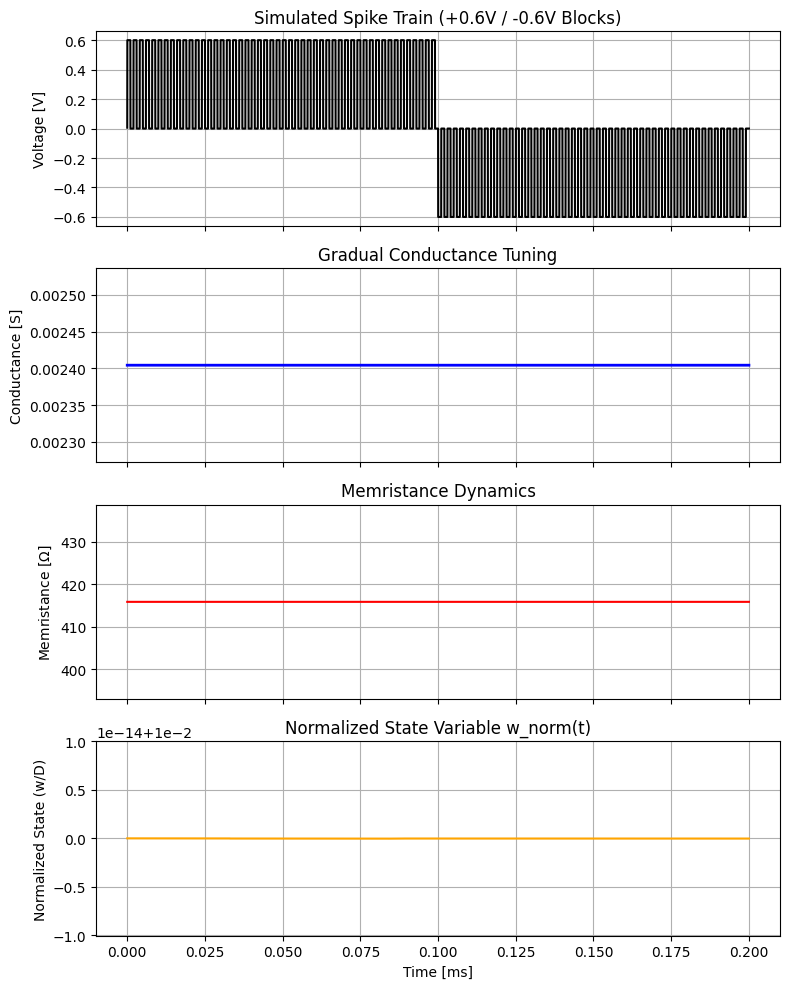

In [211]:
def run_spike_test():
    print("Starting exact physical simulation...")
    circuit = Circuit('Zhang Memristor HFT Plasticity Test')
    circuit.subcircuit(ZhangMemristor('zhang_mem'))
    val = .6
    pwl_coords = []
    current_t = 0.0
    period = 0.002       # 2 ms period (500 Hz)
    pulse_width = 0.001  # 1 ms pulse width (50% duty cycle)
    edge_time = 1e-6     # 1 us edge time for sharp transitions

# Phase 1: Potentiation Pulses (+3V for 0.1s)
    for _ in range(50):
        pwl_coords.append((current_t@u_s, 0@u_V))
        current_t += edge_time
        pwl_coords.append((current_t@u_s, val@u_V))
        current_t += pulse_width
        pwl_coords.append((current_t@u_s, val@u_V))
        current_t += edge_time
        pwl_coords.append((current_t@u_s, 0@u_V))
        current_t += (period - pulse_width - 2*edge_time)

# Phase 2: Depression Pulses (-3V for 0.1s)
    for _ in  range(50):
        pwl_coords.append((current_t@u_s, 0@u_V))
        current_t += edge_time
        pwl_coords.append((current_t@u_s, -val@u_V))
        current_t += pulse_width
        pwl_coords.append((current_t@u_s, -val@u_V))
        current_t += edge_time
        pwl_coords.append((current_t@u_s, 0@u_V))
        current_t += (period - pulse_width - 2*edge_time)

    circuit.PieceWiseLinearVoltageSource('Vpulse', 'n1', circuit.gnd, values=pwl_coords)
  

    
 
    circuit.X('M1', 'zhang_mem', 'n1', circuit.gnd)
    

  
    
    # Run the Simulation
    simulator = circuit.simulator(temperature=25, nominal_temperature=25)
    simulator.initial_condition(**{'xm1.w_node': 0.01}) 
    
    analysis = simulator.transient(step_time=1@u_us, end_time=0.2@u_s, use_initial_condition=True)

    time_ms = np.array(analysis.time)  
    voltage = np.array(analysis.nodes['n1'])
    
    try:
        w_norm_val = np.array(analysis.nodes['xm1.w_node'])
    except KeyError:
        w_norm_val = np.array(analysis.nodes['xM1:w_node'])
     
    w_norm_val = np.clip(w_norm_val, 0.0, 1.0)
    
    D, Ron, Roff = 3e-9, 10.0, 420.0
    R_array = Ron * w_norm_val + Roff * (1.0 - w_norm_val)
    G_array = 1.0 / R_array
    
    print(circuit)
    
    # Render Output Figures
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, sharex=True, figsize=(8, 10))
    
    ax1.plot(time_ms, voltage, color='black')
    ax1.set_ylabel('Voltage [V]')
    ax1.set_title('Simulated Spike Train (+0.6V / -0.6V Blocks)')
    ax1.grid(True)

    ax2.plot(time_ms, G_array, color='blue', linewidth=2)
    ax2.set_ylabel('Conductance [S]')
    ax2.set_title('Gradual Conductance Tuning')
    ax2.grid(True)
    
    ax3.plot(time_ms, R_array, color='red')
    ax3.set_ylabel('Memristance [$\Omega$]')
    ax3.set_title('Memristance Dynamics')
    ax3.grid(True)
    
    ax4.plot(time_ms, w_norm_val, color='orange')
    ax4.set_xlabel('Time [ms]')
    ax4.set_ylabel('Normalized State (w/D)')
    ax4.set_title('Normalized State Variable w_norm(t)')
    ax4.grid(True)
     
    plt.tight_layout()
    plt.show()

run_spike_test()


In [ ]:
def f_w(w):
    f = 1 - pow((2 * w)/3e-9, 4 )
    return f 
 
for i in range( ):
    
    w = f_w(i)
    print(w)

TypeError: 'float' object cannot be interpreted as an integer